## 1. Loading dependencies and data processing

In [71]:
import numpy as np
import pandas as pd
from numpy.linalg import inv
import argparse
import pymc as pm
import arviz as az
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
import ajr_causalpy_iv as ajr
import pytensor
from FreqIV import iv2sls




%load_ext autoreload
%autoreload 2



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [72]:
path = r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta"

df = pd.read_stata(path)

print(df.columns.tolist())

pd.set_option("display.max_rows", None)     # show all rows
pd.set_option("display.max_columns", None)  
non_missing = df['logem4'].notna()
non_missing_rows = df[df['logem4'].notna()]
print("Observations with non-missing logem4 values:")
print(non_missing_rows[['logem4'] + ['shortnam']])  

total_rows  = len(df)
name_col = df['shortnam']

print(f"Non‑missing settler mortality observations: {non_missing.sum()}")
print(f"Total rows in file: {total_rows}")




['shortnam', 'africa', 'lat_abst', 'rich4', 'avexpr', 'logpgp95', 'logem4', 'asia', 'loghjypl', 'baseco']
Observations with non-missing logem4 values:
       logem4 shortnam
0    4.540098      AFG
1    5.634789      AGO
3    4.232656      ARG
5    2.145931      AUS
8    5.634789      BDI
10   5.585449      BEN
11   5.634789      BFA
12   4.268438      BGD
15   4.442651      BHS
18   5.095589      BLZ
19   4.262680      BOL
20   4.262680      BRA
21   4.442651      BRB
24   5.634789      CAF
25   2.778819      CAN
27   4.232656      CHL
28   4.770685      CHN
29   6.504288      CIV
30   5.634789      CMR
31   5.480639      COG
32   4.262680      COL
35   4.357990      CRI
38   3.258096      DJI
40   4.867535      DOM
41   4.359270      DZA
42   4.262680      ECU
43   4.216562      EGY
47   3.258096      ETH
49   2.433613      FJI
50   1.057790      FRA
51   5.634789      GAB
52   0.936093      GBR
54   6.504288      GHA
55   6.180017      GIN
56   7.293018      GMB
57   5.103883      GN

### 2. Replicating main result of Acemoglu et al.

In [73]:


path = r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta"
df = pd.read_stata(path)
cols = ["logpgp95", "avexpr", "logem4"]
df_ = (df.loc[df["baseco"] == 1, cols]
         .dropna()
         .copy())

y = df_["logpgp95"].to_numpy().reshape(-1, 1)
x_endog = df_[["avexpr"]].to_numpy()                # endogenous regressor
const = np.ones((len(df_), 1))
X = np.column_stack([const, x_endog])  
z_excl = df_[["logem4"]].to_numpy()
Z = np.column_stack([const, z_excl])                # instruments [1, logem4]


beta, se, u, V = iv2sls(y, X, Z)

print(f"_cons  {beta[0,0]:.6f}  ({se[0,0]:.6f})")
print(f"avexpr {beta[1,0]:.6f}  ({se[1,0]:.6f})")


_cons  1.909667  (1.026727)
avexpr 0.944279  (0.156525)


### 3. Zero-First-Stage Test

In [76]:

path2 = r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta"
df2 = pd.read_stata(path2)
cols2 = ["logpgp95", "avexpr", "logem4"]
df2_ = (df2.loc[df2["baseco"] != 1, cols2]
         .dropna()
         .copy())

y = df2_["logpgp95"].to_numpy().reshape(-1, 1)
x_endog = df2_[["avexpr"]].to_numpy()                # endogenous regressor
const = np.ones((len(df2_), 1))
X = np.column_stack([const, x_endog])  
z_excl = df2_[["logem4"]].to_numpy()
Z = np.column_stack([const, z_excl])                # instruments [1, logem4]


beta, se, u, V = iv2sls(y, X, Z)

print(f"_cons  {beta[0,0]:.6f}  ({se[0,0]:.6f})")
print(f"avexpr {beta[1,0]:.6f}  ({se[1,0]:.6f})")


_cons  3.587178  (3.165367)
avexpr 0.671933  (0.391680)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, gamma, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 68 seconds.


      mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk   ess_tail  \
beta   1.1  0.3046  0.5442   1.6732     0.0073   0.0047  1761.5316  2623.2819   

       r_hat  
beta  1.0023  


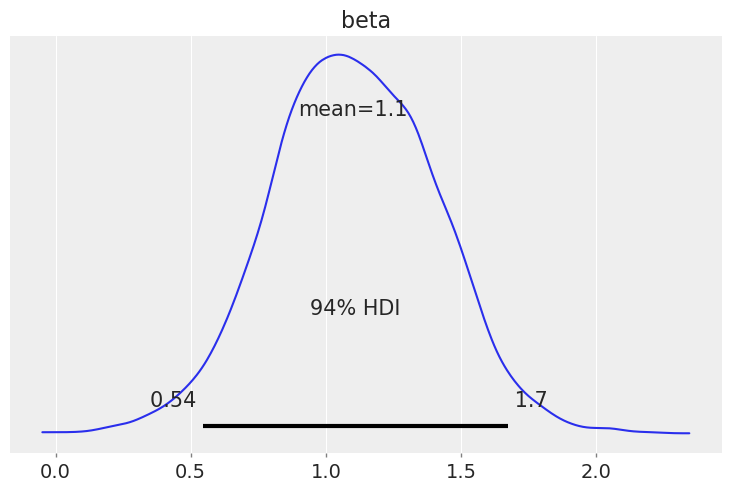

In [ ]:


# ---- 1) Load AJR data and build the design matrices ------------------------
path = r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta"
df = pd.read_stata(path)

# baseline sample (optional)
df = df[df["baseco"] == 1].reset_index(drop=True)

# Reproduce the 'other_cont' dummy used in your scripts (AUS, MLT, NZL)
if "other_cont" not in df.columns and "shortnam" in df.columns:
    df["other_cont"] = 0
    df.loc[df["shortnam"].isin(["AUS","MLT","NZL"]), "other_cont"] = 1

# variables
y = df["logpgp95"].to_numpy()
x = df["avexpr"].to_numpy()
z = df["logem4"].to_numpy()
Wcols = [c for c in ["lat_abst","africa","asia","other_cont"] if c in df.columns]
W = df[Wcols].to_numpy() if Wcols else np.empty((len(df), 0))

# add intercepts
Zmat = np.column_stack([np.ones(len(df)), z, W])     # instruments + controls (first-stage)
Wtil = np.column_stack([np.ones(len(df)), W])        # controls + intercept (second-stage)

# ---- 2) First stage: OLS x on [Z,W] → xhat ---------------------------------
# gamma_hat = (Z'Z)^{-1} Z' x ; xhat = Z gamma_hat
gamma_hat, *_ = np.linalg.lstsq(Zmat, x, rcond=None)
xhat = Zmat @ gamma_hat

# ---- 3) Second stage: Bayesian OLS y on [xhat, W] with flat/Jeffreys priors -
with pm.Model() as bayes_2sls:
    # Priors that reproduce OLS: coefficients ~ Flat; sigma ~ Jeffreys (HalfFlat on σ)
    beta = pm.Flat("beta")                                   # coefficient on xhat
    gamma = pm.Flat("gamma", shape=Wtil.shape[1])            # intercept + W coefficients
    sigma = pm.HalfFlat("sigma")                             # p(σ) ∝ 1/σ  (Jeffreys for σ)

    mu = beta * xhat + (Wtil @ gamma)
    pm.Normal("y", mu=mu, sigma=sigma, observed=y)

    idata = pm.sample(2000, tune=1000, chains=4, cores=4, target_accept=0.95, random_seed=42)

# ---- 4) Results: posterior for beta matches 2SLS (homoskedastic) -----------
print(az.summary(idata, var_names=["beta"], round_to=4))
az.plot_posterior(idata, var_names=["beta"]);


## 2. Bayesian replication w/ covariates

In [11]:


# Load the data
data_path = r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta"
df_ajr = ajr.load_ajr_data(data_path, baseline_only=True)


# Run the model with pre-processed data
iv = ajr.run(
    data=df_ajr,  # Pass the filtered dataframe 
    priors=None, 
    draws=2000, 
    tune=1000, 
    chains=4, 
    cores=4,
    target_accept=0.95, 
    loosen_exclusion=False,
    covariates=['asia', 'africa', 'other_cont', 'lat_abst'],
    netcdf_path="ajr_iv_posterior.nc"
)

Original dataset size: 163
After baseco == 1 filter: 64
After dropna: 64 observations
First-stage formula: avexpr ~ 1 + asia + africa + other_cont + lat_abst + logem4
Structural formula: logpgp95 ~ 1 + avexpr + asia + africa + other_cont + lat_abst


c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\causalpy\experiments\instrumental_variable.py:161: UserWarning: Warning. The treatment variable is not Binary.
                This is not necessarily a problem but it violates
                the assumption of a simple IV experiment.
                The coefficients should be interpreted appropriately.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta_t, beta_z, chol_cov]


Output()

ValueError: Not enough samples to build a trace.

In [3]:
ajr.get_available_covariates(data=df_ajr)

['africa', 'asia', 'lat_abst', 'loghjypl', 'other_cont', 'rich4']

array([[<Axes: title={'center': 'beta_z\nIntercept'}>,
        <Axes: title={'center': 'beta_z\navexpr'}>,
        <Axes: title={'center': 'beta_z\nasia'}>],
       [<Axes: title={'center': 'beta_z\nafrica'}>,
        <Axes: title={'center': 'beta_z\nother_cont'}>,
        <Axes: title={'center': 'beta_z\nlat_abst'}>]], dtype=object)

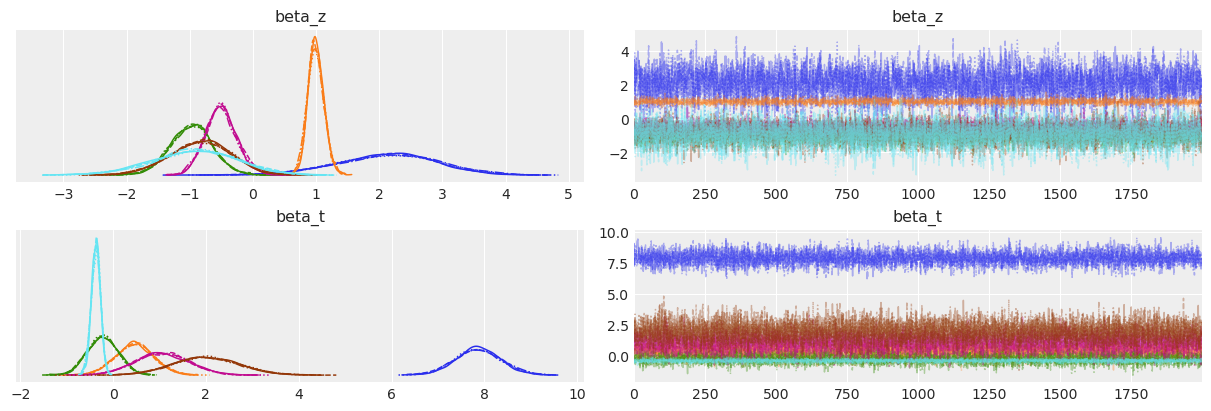

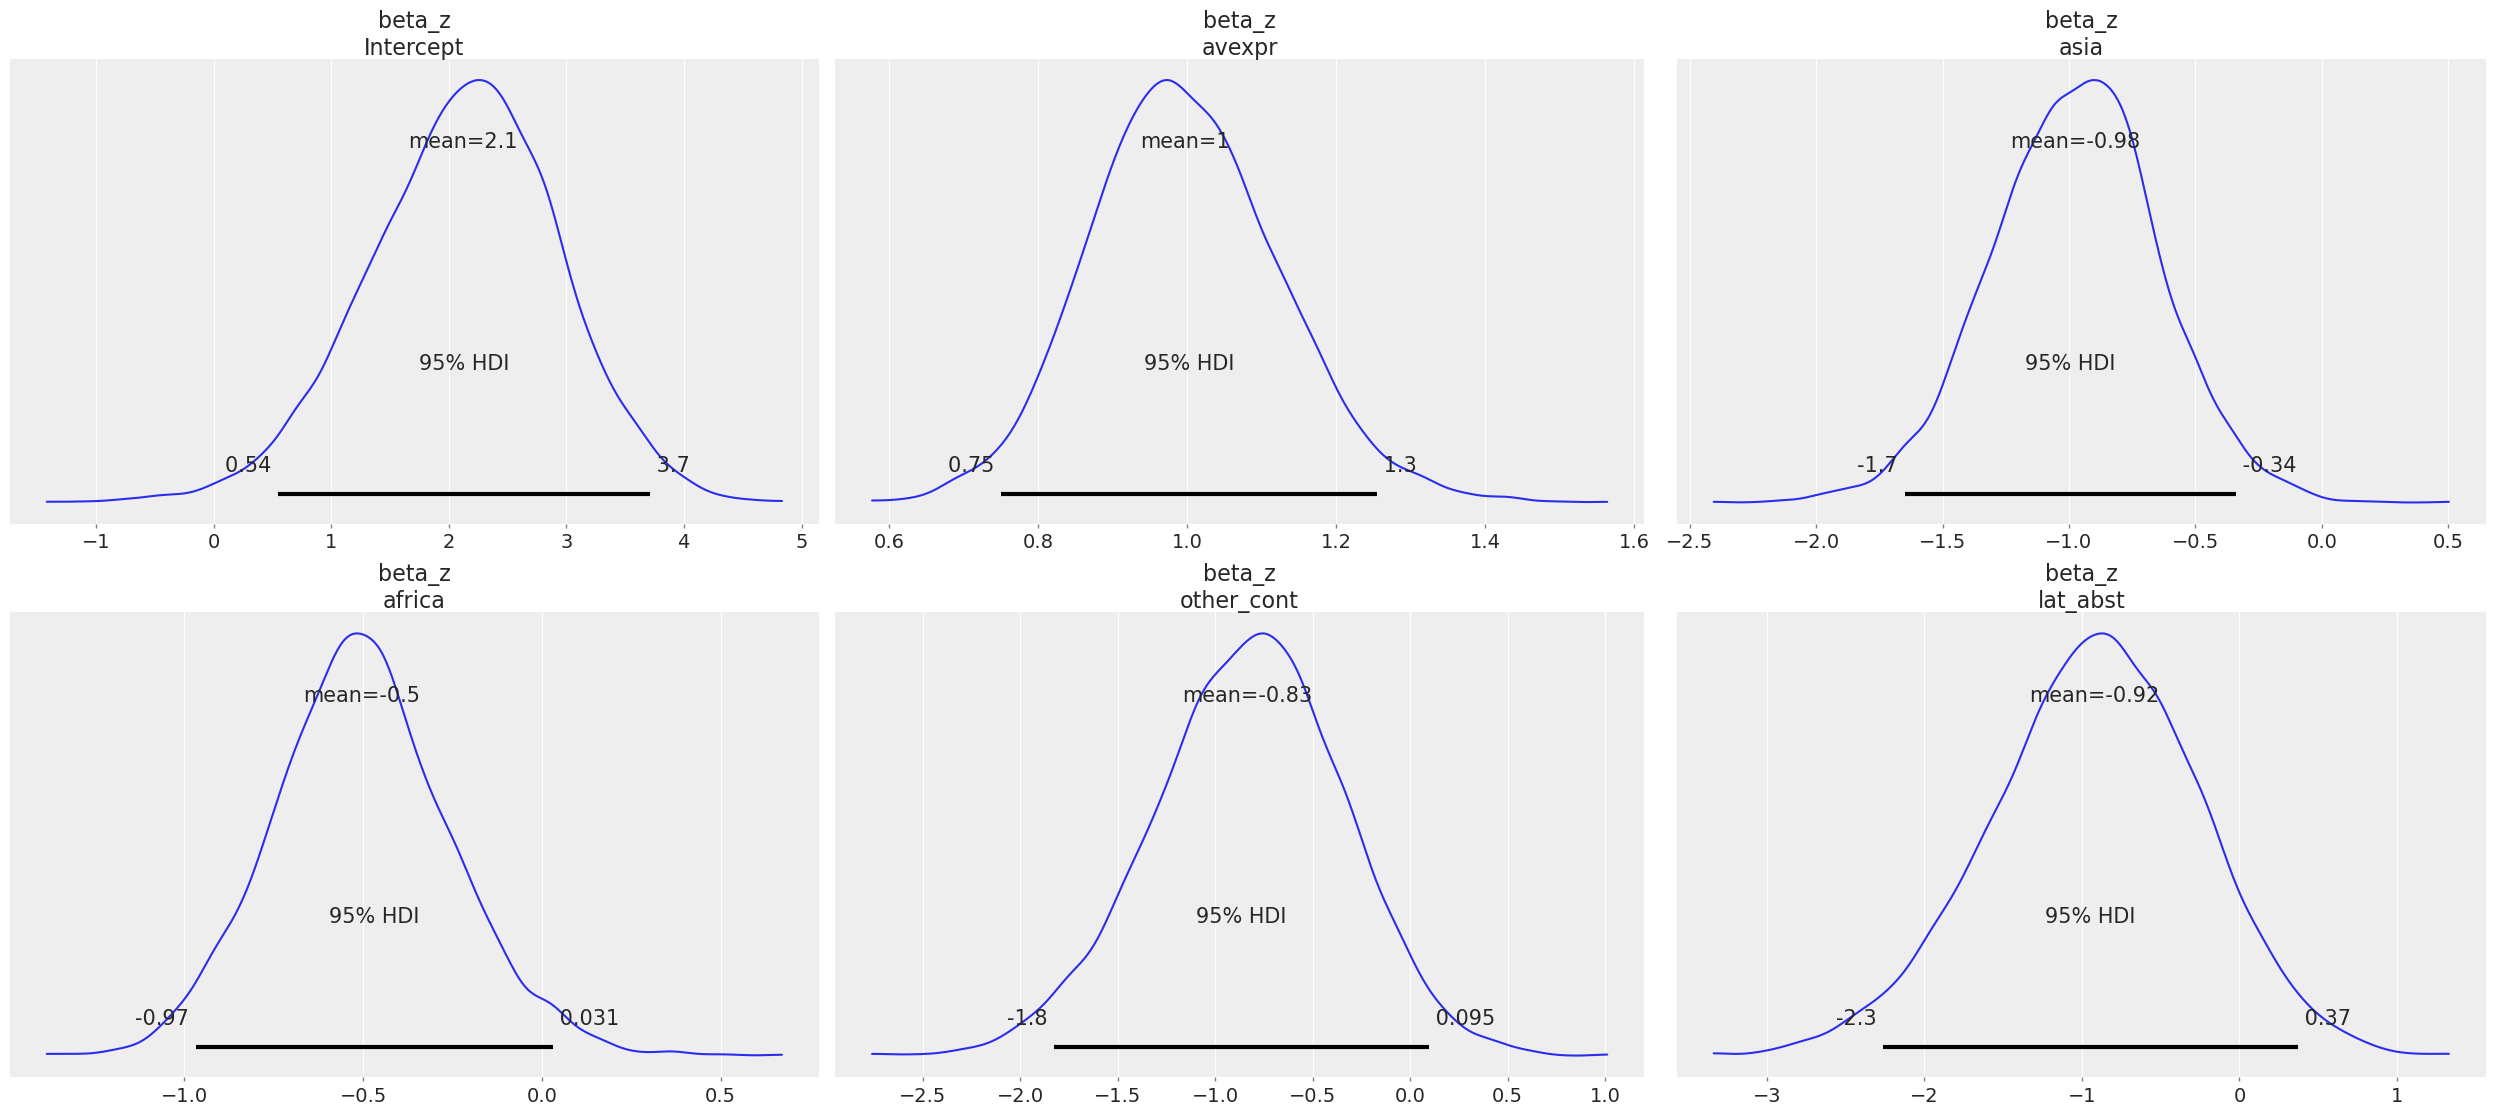

In [4]:
idata = az.from_netcdf("ajr_iv_posterior.nc")
az.plot_trace(idata, var_names=["beta_z", "beta_t"])
az.plot_posterior(idata, var_names=["beta_z"], hdi_prob=0.95)


Shape check - first_stage_preds: (4, 2000, 64), observed_avexpr: (64,)
Instrument relevance (logem4 vs avexpr): -0.520
Rule of thumb: Should be > 0.3 for reasonable instrument strength
First-stage R-squared: -0.180


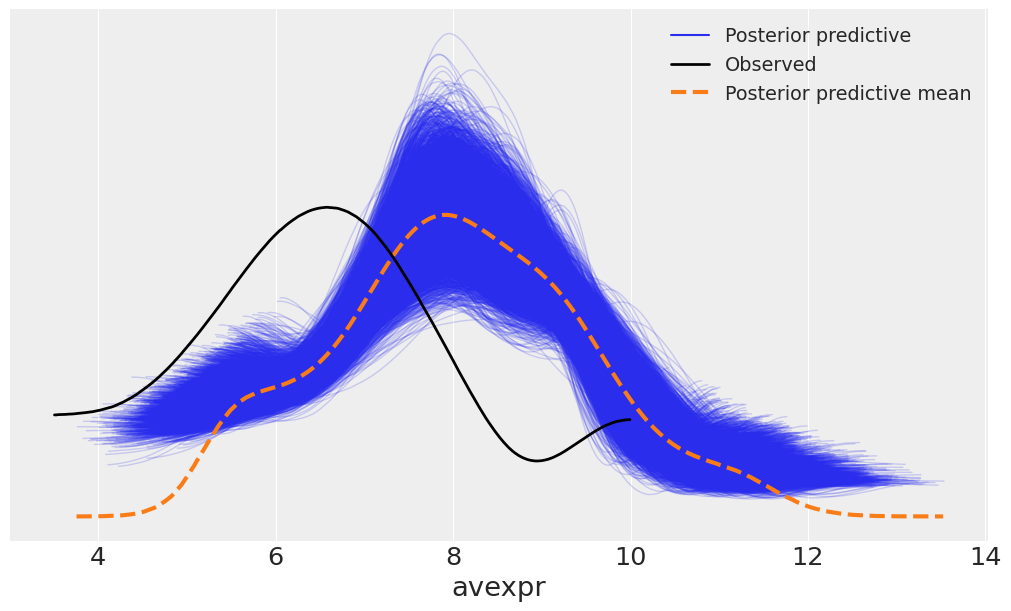

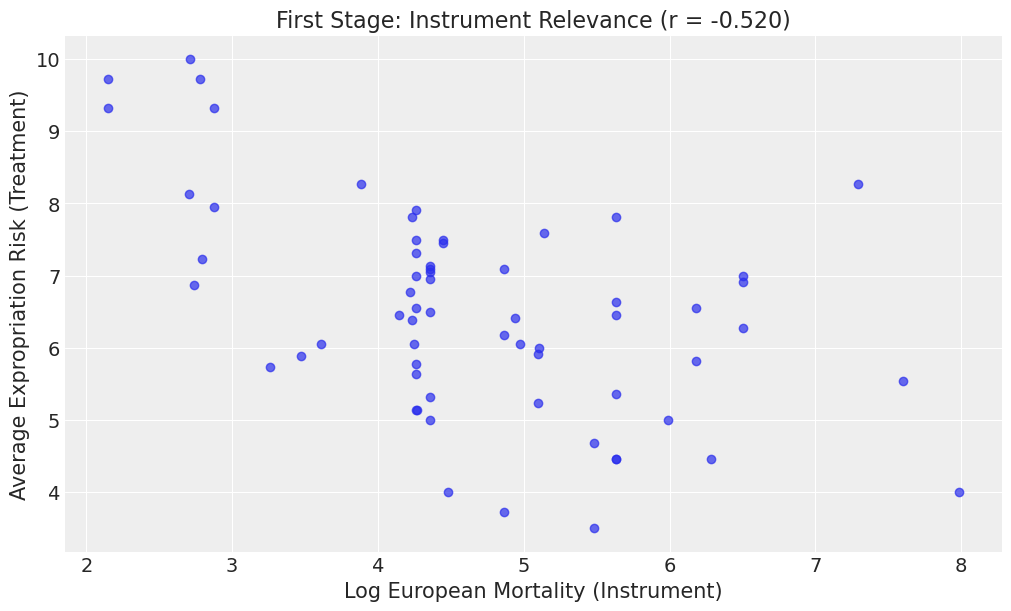

In [5]:
# Check instrument relevance - first stage correlation between instrument and treatment
import xarray as xr

# Use the same filtered data from above
first_stage_preds = idata.posterior['mu'].isel(mu_dim_1=0)  # First stage predictions
observed_avexpr = df_ajr['avexpr'].values

print(f"Shape check - first_stage_preds: {first_stage_preds.shape}, observed_avexpr: {observed_avexpr.shape}")

# CORRECT instrument relevance check: correlation between instrument (logem4) and treatment (avexpr)
instrument_treatment_corr = np.corrcoef(df_ajr['logem4'], df_ajr['avexpr'])[0,1]
print(f"Instrument relevance (logem4 vs avexpr): {instrument_treatment_corr:.3f}")
print("Rule of thumb: Should be > 0.3 for reasonable instrument strength")

# First-stage model fit: how well does the model predict avexpr?
if first_stage_preds.shape[2] == len(observed_avexpr):
    # Add first-stage PPC for visualization
    idata.posterior_predictive = idata.posterior_predictive.assign(
        avexpr=first_stage_preds.rename(mu_dim_0='avexpr_dim_0')
    )
    observed_avexpr_da = xr.DataArray(
        observed_avexpr, 
        dims=['avexpr_dim_0'],
        coords={'avexpr_dim_0': range(len(observed_avexpr))}
    )
    idata.observed_data = idata.observed_data.assign(avexpr=observed_avexpr_da)

    # Plot first-stage fit
    az.plot_ppc(idata, data_pairs={"avexpr": "avexpr"}, var_names=["avexpr"], figsize=(10, 6))
    
    # Model fit metrics (R-squared equivalent)
    pred_mean = first_stage_preds.mean(['chain', 'draw'])
    ss_res = np.sum((observed_avexpr - pred_mean)**2)
    ss_tot = np.sum((observed_avexpr - np.mean(observed_avexpr))**2)
    r_squared = 1 - (ss_res / ss_tot)
    print(f"First-stage R-squared: {r_squared:.3f}")
    
    
else:
    print("ERROR: Dimension mismatch!")
    print(f"Model predictions: {first_stage_preds.shape[2]}, Data observations: {len(observed_avexpr)}")

# Additional instrument relevance plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(df_ajr['logem4'], df_ajr['avexpr'], alpha=0.7)
plt.xlabel('Log European Mortality (Instrument)')
plt.ylabel('Average Expropriation Risk (Treatment)')
plt.title(f'First Stage: Instrument Relevance (r = {instrument_treatment_corr:.3f})')
plt.show()

Computing correlations for 8000 posterior samples...

=== BAYESIAN EXCLUSION RESTRICTION TEST ===
Posterior median correlation: 0.083
95% HDI: [-0.207, 0.365]
HDI contains zero: True
✓ PASS: Cannot reject exclusion restriction (HDI contains 0)


C:\Users\B375471\AppData\Local\Temp\ipykernel_7480\2327672217.py:101: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


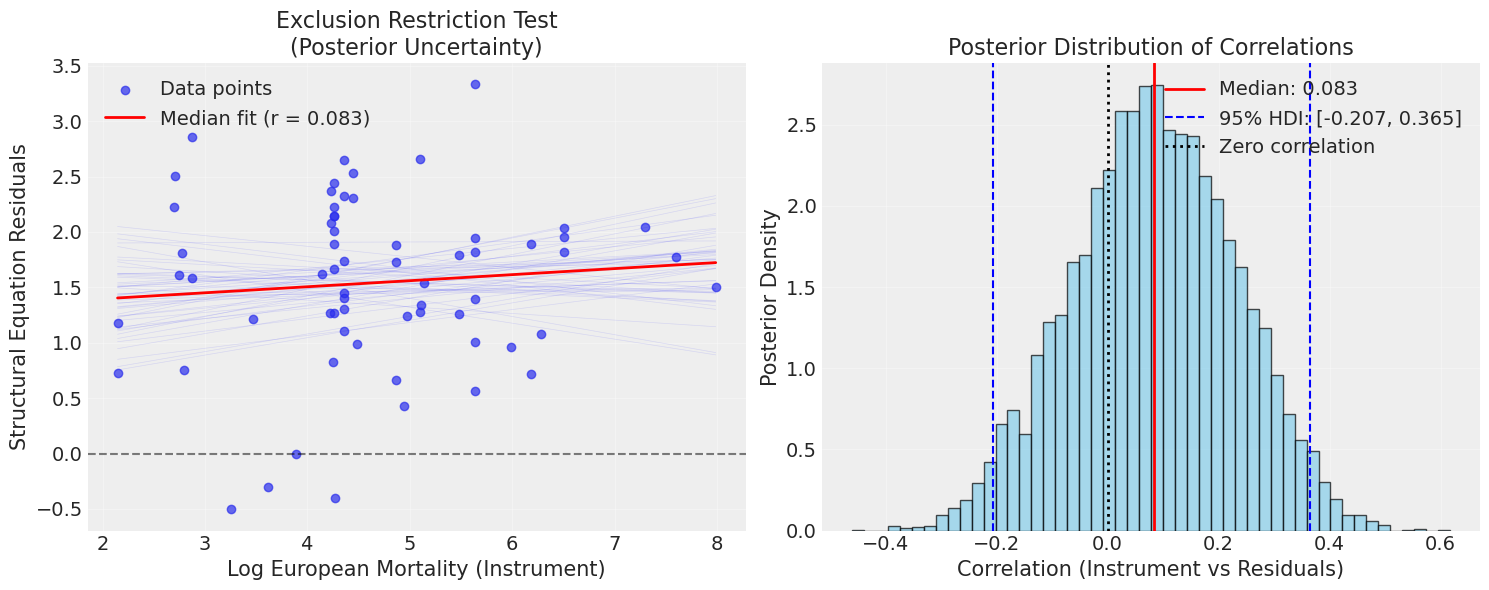


Interpretation:
✓ STRONG SUPPORT: Low correlation and HDI contains 0

Diagnostic Information:
Standard deviation of posterior correlations: 0.1471
Range of correlations: [-0.461, 0.617]


In [6]:
# Check if residuals from both equations are uncorrelated with instrument
# This tests the exclusion restriction using BAYESIAN POSTERIOR SAMPLES
import xarray as xr

# Use the same filtered data and predictions from previous cells
first_stage_preds = idata.posterior['mu'].isel(mu_dim_1=0)  # First stage (avexpr) predictions
structural_preds = idata.posterior['mu'].isel(mu_dim_1=1)  # Structural (logpgp95) predictions

# Calculate residuals for each posterior sample
observed_logpgp95 = df_ajr['logpgp95'].values
observed_logem4 = df_ajr['logem4'].values

# Calculate correlations for each posterior sample
n_chains, n_draws, n_obs = structural_preds.shape
correlations_posterior = []

print(f"Computing correlations for {n_chains * n_draws} posterior samples...")

for chain in range(n_chains):
    for draw in range(n_draws):
        # Get residuals for this posterior sample
        pred_logpgp95 = structural_preds[chain, draw, :].values
        residuals = observed_logpgp95 - pred_logpgp95
        
        # Calculate correlation between instrument and residuals
        corr = np.corrcoef(observed_logem4, residuals)[0, 1]
        correlations_posterior.append(corr)

correlations_posterior = np.array(correlations_posterior)

# Calculate HDI from posterior samples
hdi_lower = np.percentile(correlations_posterior, 2.5)
hdi_upper = np.percentile(correlations_posterior, 97.5)
corr_median = np.median(correlations_posterior)

print(f"\n=== BAYESIAN EXCLUSION RESTRICTION TEST ===")
print(f"Posterior median correlation: {corr_median:.3f}")
print(f"95% HDI: [{hdi_lower:.3f}, {hdi_upper:.3f}]")

# Test if HDI contains zero
contains_zero = hdi_lower <= 0 <= hdi_upper
print(f"HDI contains zero: {contains_zero}")

if contains_zero:
    print("✓ PASS: Cannot reject exclusion restriction (HDI contains 0)")
else:
    print("✗ FAIL: Evidence against exclusion restriction (HDI excludes 0)")

# Visualization using posterior samples
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left plot: Scatter with median residuals
median_residuals = observed_logpgp95 - structural_preds.mean(['chain', 'draw']).values
ax1.scatter(observed_logem4, median_residuals, alpha=0.7, label='Data points')

# Show uncertainty with individual posterior samples (subsample for clarity)
n_sample_lines = 50
sample_indices = np.random.choice(len(correlations_posterior), n_sample_lines, replace=False)

for i, idx in enumerate(sample_indices):
    chain_idx = idx // n_draws
    draw_idx = idx % n_draws
    
    pred_sample = structural_preds[chain_idx, draw_idx, :].values
    residuals_sample = observed_logpgp95 - pred_sample
    
    # Fit line for this sample
    slope, intercept = np.polyfit(observed_logem4, residuals_sample, 1)
    line_x = np.linspace(observed_logem4.min(), observed_logem4.max(), 100)
    line_y = slope * line_x + intercept
    
    ax1.plot(line_x, line_y, 'blue', alpha=0.1, linewidth=0.5)

# Overall median line
median_slope, median_intercept = np.polyfit(observed_logem4, median_residuals, 1)
line_x = np.linspace(observed_logem4.min(), observed_logem4.max(), 100)
median_line_y = median_slope * line_x + median_intercept
ax1.plot(line_x, median_line_y, 'red', linewidth=2, label=f'Median fit (r = {corr_median:.3f})')

ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax1.set_xlabel('Log European Mortality (Instrument)')
ax1.set_ylabel('Structural Equation Residuals')
ax1.set_title('Exclusion Restriction Test\n(Posterior Uncertainty)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right plot: Posterior distribution of correlations
ax2.hist(correlations_posterior, bins=50, alpha=0.7, density=True, color='skyblue', edgecolor='black')
ax2.axvline(corr_median, color='red', linestyle='-', linewidth=2, label=f'Median: {corr_median:.3f}')
ax2.axvline(hdi_lower, color='blue', linestyle='--', label=f'95% HDI: [{hdi_lower:.3f}, {hdi_upper:.3f}]')
ax2.axvline(hdi_upper, color='blue', linestyle='--')
ax2.axvline(0, color='black', linestyle=':', linewidth=2, label='Zero correlation')
ax2.set_xlabel('Correlation (Instrument vs Residuals)')
ax2.set_ylabel('Posterior Density')
ax2.set_title('Posterior Distribution of Correlations')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary assessment
print(f"\nInterpretation:")
if abs(corr_median) < 0.1 and contains_zero:
    print("✓ STRONG SUPPORT: Low correlation and HDI contains 0")
elif abs(corr_median) < 0.2 and contains_zero:
    print("✓ MODERATE SUPPORT: Modest correlation but HDI contains 0")
elif contains_zero:
    print("⚠ WEAK SUPPORT: High correlation but HDI still contains 0")
else:
    print("✗ NO SUPPORT: Correlation significantly different from 0")

# Additional diagnostic: Show how much uncertainty comes from posterior vs sampling
print(f"\nDiagnostic Information:")
print(f"Standard deviation of posterior correlations: {np.std(correlations_posterior):.4f}")
print(f"Range of correlations: [{np.min(correlations_posterior):.3f}, {np.max(correlations_posterior):.3f}]")

c:\Users\B375471\Anaconda3\envs\pymc_env\Lib\site-packages\arviz\plots\backends\matplotlib\pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


array([[<Axes: ylabel='beta_t\nIntercept'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta_t\nasia'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta_t\nafrica'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta_t\nother_cont'>, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta_t\nlat_abst'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta_t\nlogem4'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='beta_z\nIntercept'>, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='beta_t\nIntercept', ylabel='beta_z\navexpr'>,
        <Axes: xlabel='beta_t\nasia'>, <Axes: xlabel='beta_t\nafrica'>,
        <

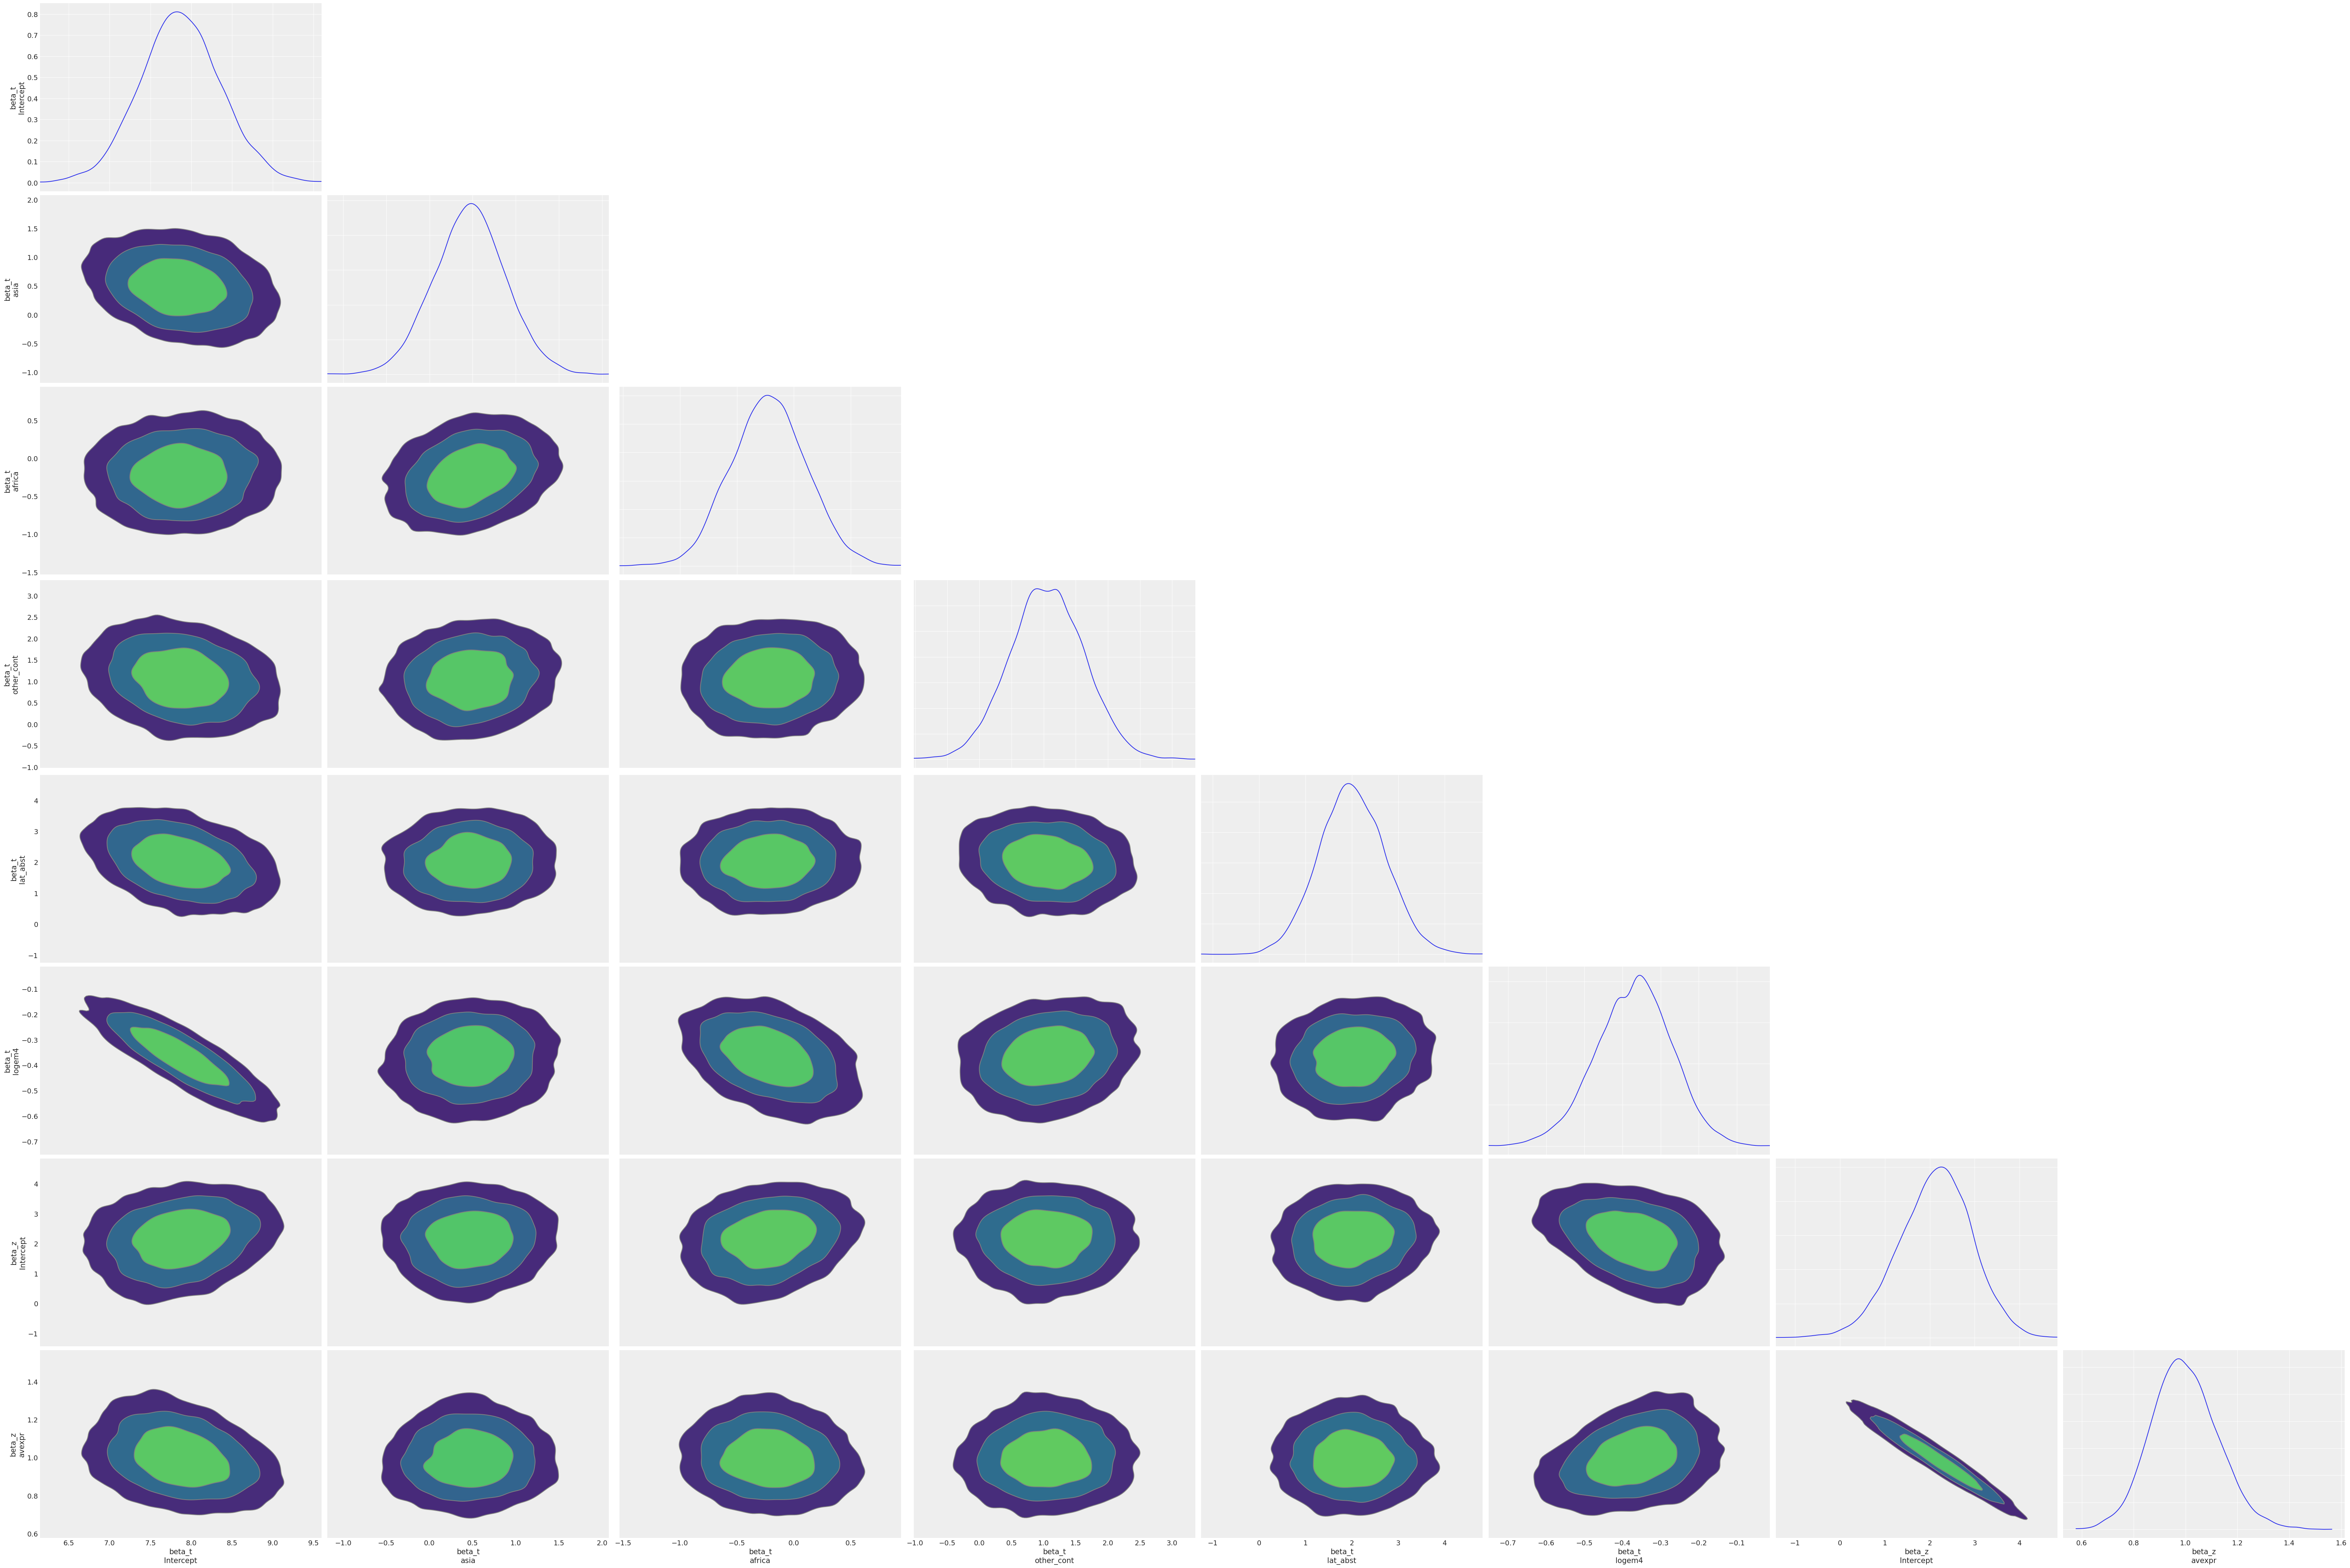

In [7]:
# 1. pull out the pieces of the 2×2 covariance matrix
cov = idata.posterior["cov"]        # dims: (chain, draw, cov_dim_0, cov_dim_1)

σ_uv = cov.sel(cov_dim_0=0, cov_dim_1=1)       # off‑diagonal element
σ_u2 = cov.sel(cov_dim_0=0, cov_dim_1=0)       # variance of u
σ_v2 = cov.sel(cov_dim_0=1, cov_dim_1=1)       # variance of v

# 2. turn it into the correlation ρ
rho = σ_uv / (σ_u2**0.5 * σ_v2**0.5)

# 3. store it inside the InferenceData so ArviZ can see it
idata.posterior["rho"] = rho               # or idata = idata.assign(rho=rho)

# 
az.plot_pair(
    idata,
    var_names=["beta_t", "beta_z", "rho"],
    kind="kde",
    marginals=True,
    divergences=True,
)


Observed logpgp95 mean: 8.142
Predicted logpgp95 mean: 6.521
Observed logpgp95 std: 1.052
Predicted logpgp95 std: 0.906


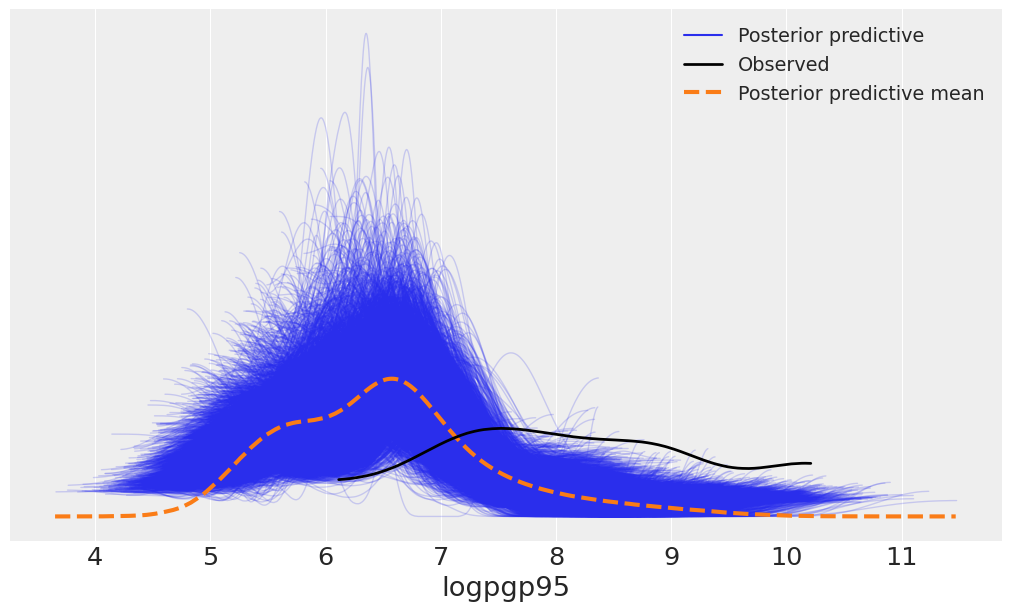

In [8]:
# Create proper posterior predictive data and use az.plot_ppc
import xarray as xr

# Extract structural equation predictions (logpgp95)
structural_preds = idata.posterior['mu'].isel(mu_dim_1=1)  # logpgp95 predictions

# Get observed logpgp95 values
df_ajr = pd.read_stata(r"C:\Users\B375471\Downloads\Acemoglu_osv\colonial_origins\maketable4\maketable4.dta")
df_ajr = df_ajr.dropna(subset=['logem4', 'logpgp95', 'avexpr'])  # Same filtering as in ajr module
observed_logpgp95 = df_ajr['logpgp95'].values

# Add the logpgp95 predictions to posterior_predictive group
idata.posterior_predictive = idata.posterior_predictive.assign(
    logpgp95=structural_preds.rename(mu_dim_0='logpgp95_dim_0')
)

# Add the observed logpgp95 data to observed_data group
observed_da = xr.DataArray(
    observed_logpgp95, 
    dims=['logpgp95_dim_0'],
    coords={'logpgp95_dim_0': range(len(observed_logpgp95))}
)
idata.observed_data = idata.observed_data.assign(logpgp95=observed_da)

# Remove likelihood from both groups to avoid confusion
idata.posterior_predictive = idata.posterior_predictive.drop_vars('likelihood')
idata.observed_data = idata.observed_data.drop_vars('likelihood')

# Now use az.plot_ppc with proper data - specify only logpgp95
az.plot_ppc(
    idata,
    data_pairs={"logpgp95": "logpgp95"},
    var_names=["logpgp95"],  # Only plot logpgp95, not likelihood
    figsize=(10, 6),
)

print(f"Observed logpgp95 mean: {observed_logpgp95.mean():.3f}")
print(f"Predicted logpgp95 mean: {structural_preds.mean().values:.3f}")
print(f"Observed logpgp95 std: {observed_logpgp95.std():.3f}")
print(f"Predicted logpgp95 std: {structural_preds.std().values:.3f}")